# Lesson 8: DDM vs probit on the Garcia magnitude task

In lessons 1–4 we modelled **only the choice** participants made on each trial:
"did they pick the larger number?" — fit with a Bernoulli likelihood
(`MagnitudeComparisonModel`). That model recovers the Bayesian-observer
front-end (priors, asymmetric encoding noise, posterior shrinkage) entirely
from choice probabilities.

But choice isn't the only thing the participant gives us. They also took a
specific amount of *time* to make that choice. **The reaction time (RT) is a
second observation** generated by the same underlying perceptual process. A
drift-diffusion model (DDM) makes that explicit: the same posterior log-magnitude
that drives the choice also drives the *speed* of accumulation. So a DDM fit to
(rt, choice) jointly should — in principle — give us tighter inference on the
same cognitive parameters.

This lesson is a focused two-model comparison:

- `MagnitudeComparisonModel` (lesson 1) — choice-only Bernoulli with Bayesian
  observer.
- `DDMMagnitudeComparisonModel` (this lesson) — same Bayesian observer, but
  choice and RT are modelled jointly via a Wiener first-passage-time (WFPT)
  likelihood.

Both share the **identical cognitive front-end**. The only thing that changes
is the decision rule: one-shot Bernoulli vs stochastic single-accumulator
race. **Fitting the DDM is a one-line change** from the probit if you have
RT in the dataframe — same constructor signature, same `.sample()`, same
idata: swap `MagnitudeComparisonModel` for `DDMMagnitudeComparisonModel`.

We run on the full **64-subject Garcia 2022 magnitude task** because at
$n = 8$ the cognitive parameters are weakly identified and the comparison
between models is noisy.

[Lesson 9](lesson9.ipynb) extends this and adds the **race-diffusion** model
(two parallel accumulators), which captures the slow-error pattern in
choice-conditional RT that single-accumulator DDMs cannot.

## Before we fit: drop physiologically implausible fast trials

**Critical preprocessing step for any DDM/RDM fit — including yours.**

DDM/RDM likelihoods require the non-decision time $t_0$ to be **below
$\min(\text{RT})$ for every subject**. When the sampler wanders into a
region where $t_0 > \text{rt}$ for some trial, the WFPT log-likelihood
floors at `LOGP_LB = -66.1` (HSSM's design, inherited by bauer) — and
**the gradient w.r.t. $t_0$ in that region is exactly zero**. NUTS sees
a flat landscape, loses all pull back into the valid region, and the
chain can permanently stick in a wrong posterior mode. We diagnosed this
the hard way on a first attempt at fitting Garcia (chains landed in 4
different basins, $\hat r = 4$, ESS = 4).

The standard fix is **dropping trials with RT below typical motor
non-decision time**, around 150–250 ms depending on the task. These
trials almost certainly represent anticipatory responses or motor
preparation that fired before the stimulus was fully processed — not
stimulus-driven decisions. Rationale, with sources:

- **Luce (1986)**, *Response Times*, ch. 6: simple key-press RTs have an
  irreducible physiological floor around 100–150 ms (visual transduction
  + motor latency), so anything faster cannot reflect a perceptual
  decision.
- **Ratcliff (1993)**, *Methods for dealing with reaction time outliers*
  (Psychol. Bull.): formalised RT outlier handling in cognitive
  modelling. The standard recommendation is to drop a thin slice of the
  fastest and slowest RTs (or fit a mixture with a contaminant
  distribution), with the fast cutoff typically around 200–300 ms for
  perceptual / numerical comparison tasks.
- **Wiecki, Sofer & Frank (2013)**, HDDM paper: the same convention
  built into the HDDM toolbox's default outlier handling.

For Garcia 2022 we use **`rt >= 0.20 s`**, which drops 2.1 % of trials
(285 of 13,410). This matches bauer's default $t_0$ prior centre, sits
just above Luce's physiological floor, and falls comfortably below the
bulk of real responses (the empirical RT distribution peaks around
320 ms — see the chronometric curves later). For tasks with slower
typical responses (e.g. perceptual decisions with longer integration
windows) a 250–300 ms cutoff would be more appropriate; for very fast
tasks (saccadic RT) it could be lower. The principle is the same:
**make the prior on $t_0$ and the empirical $\min(\text{rt})$
compatible**.

bauer's `DDMMagnitudeComparisonModel` now also writes a warning to
stderr at model-build time if it sees any trials below 0.20 s, so this
won't silently bite you on a future dataset.

### Porting to your own data — the dataframe schema

For the rest of this lesson to work on your data, your trial dataframe
needs:

| | required | type |
|---|---|---|
| `subject` | index level or column | int / str |
| `n1`, `n2` | columns | numeric — the two compared values (any unit) |
| `choice` | column | `bool`, `True` = chose option 2 |
| `rt` | column | seconds, > 0 |

If you have an extra design factor (group, condition, ISI, …) keep it as
a column too — the [regression-DDM section](#bonus-recipe-regression-ddm-for-between-group-or-within-design-effects) below shows how to use it.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

sns.set_theme(context='notebook', style='whitegrid', palette='deep')

from bauer.utils.data import load_garcia2022
from bauer.utils import get_subject_posterior_df
from bauer.models import MagnitudeComparisonModel, DDMMagnitudeComparisonModel

# Load the full Garcia 2022 magnitude task (all 64 subjects).
df = load_garcia2022(task='magnitude')
n_subj = df.index.get_level_values('subject').nunique()
print(f"Subjects: {n_subj}")
print(f"Trials:   {len(df)}  (~{len(df) // n_subj} per subject)")
print(f"Columns:  {list(df.columns)}")

# ── Preprocess: drop physiologically implausible fast trials ──────────────
# Crucial for DDM/RDM fits, see the explanation in the next markdown cell.
RT_MIN = 0.20   # seconds; matches the default t0 prior centre in bauer.
n_before = len(df)
df = df[df['rt'] >= RT_MIN].copy()
print(f"\nDropped {n_before - len(df)} / {n_before} trials with rt < {RT_MIN:.2f}s "
      f"({100*(n_before - len(df))/n_before:.1f}%); "
      f"global min rt now {df['rt'].min():.3f}s.")

# Cache directory — set BAUER_TUTORIAL_REFIT=1 in the env to force a fresh fit.
# Cache key includes the RT cutoff so different filters get different caches.
CACHE_DIR = os.path.expanduser('~/.bauer_tutorial_cache')
os.makedirs(CACHE_DIR, exist_ok=True)
FORCE_REFIT = bool(os.environ.get('BAUER_TUTORIAL_REFIT', ''))
CACHE_TAG = f'garcia_n{n_subj}_rtmin{int(RT_MIN*1000)}'

def fit_or_load(model, name, backend='numpyro', **sample_kwargs):
    """Fit (or load cached) idata. We use the numpyro JAX backend by default —
    it's ~3–10× faster on CPU than pymc and parallelises the chains on a
    single GPU. Falls back to pymc if you don't have hssm/jax/numpyro
    installed. Always (re)builds the pymc model — required for downstream
    ``model.ppc()`` even when the idata came from cache."""
    model.build_estimation_model(data=df, hierarchical=True)
    path = os.path.join(CACHE_DIR, f'{CACHE_TAG}_{name}.nc')
    if os.path.exists(path) and not FORCE_REFIT:
        print(f"Loading cached {name} fit from {path}")
        return az.from_netcdf(path)
    kw = dict(draws=1000, tune=1000, chains=4, target_accept=0.95,
              backend=backend)
    kw.update(sample_kwargs)
    idata = model.sample(**kw)
    idata.to_netcdf(path)
    print(f"Saved {name} fit to {path}")
    return idata

df.head()

Subjects: 64
Trials:   13410  (~209 per subject)
Columns:  ['n1', 'n2', 'choice', 'rt', 'accuracy', 'correct', 'isi']

Dropped 285 / 13410 trials with rt < 0.20s (2.1%); global min rt now 0.200s.


n1  n2  choice     rt  accuracy  correct  \
subject format       run trial_nr                                             
1       non-symbolic 1   1          7  10    True  0.775         1       -1   
                         2          5  14   False  0.892         0       -1   
                         3          7  14    True  0.611         1       -1   
                         4          7  10    True  0.660         1       -1   
                         5          5  10    True  0.830         1       -1   

                                     isi  
subject format       run trial_nr         
1       non-symbolic 1   1         8.033  
                         2         8.532  
                         3         6.533  
                         4         7.033  
                         5         9.033

## The two models, side by side

Both share the same Bayesian-observer cognitive front-end:

- $\nu_1, \nu_2$ — per-option encoding noise SDs (asymmetric for the sequential
  presentation: option 1 is held in memory while option 2 is shown).
- $\mu_p, \sigma_p$ — prior mean and SD over log-magnitudes.
- Posterior shrinkage weights $\beta_k = \sigma_p^2 / (\sigma_p^2 + \nu_k^2)$ —
  noisier options get pulled more toward the prior.

The **probit** model then computes a Bernoulli choice probability:

$$P(\text{choose 2}) = \Phi\!\left(\frac{\mu_{\text{post},2} - \mu_{\text{post},1}}{\sqrt{\sigma^2_{\text{post},1} + \sigma^2_{\text{post},2}}}\right)$$

The **DDM** uses the same numerator as the drift of a single Wiener accumulator:

$$\mathrm{d}X(t) = v\, \mathrm{d}t + \sigma\, \mathrm{d}W(t), \qquad
v = \frac{\mu_{\text{post},2} - \mu_{\text{post},1}}{\sqrt{\nu_1^2 + \nu_2^2}}$$

The choice is which boundary (at $\pm a$) is hit first; the RT is the
first-passage time plus a non-decision time $t_0$. Same numerator, similar
denominator. The DDM adds two parameters not present in the probit:

- $a$ — half boundary separation (controls overall RT magnitude).
- $t_0$ — non-decision time (motor + sensory delay).

Crucially the perceptual parameters $\nu_k, \mu_p, \sigma_p$ play exactly
the same role in both models. So if we fit both, those four should land in
roughly the same place — and the DDM should give us tighter intervals,
because RT carries additional information about the perceived SNR.

In [2]:
# ── Fit the probit model (choice only, fast) ──────────────────────────────
m_probit = MagnitudeComparisonModel(
    paradigm=df,
    fit_separate_evidence_sd=True,   # allow ν_1 ≠ ν_2 (sequential task)
    fit_prior=True,                  # estimate Bayesian-observer prior μ_p, σ_p
)
idata_probit = fit_or_load(m_probit, 'probit')

Loading cached probit fit from /Users/gdehol/.bauer_tutorial_cache/garcia_n64_rtmin200_probit.nc


In [3]:
# ── Fit the DDM (joint choice + RT, slower; ~10–15 min on a laptop) ───────
m_ddm = DDMMagnitudeComparisonModel(
    paradigm=df,
    fit_separate_evidence_sd=True,
    fit_prior=True,
)
idata_ddm = fit_or_load(m_ddm, 'ddm')

Loading cached ddm fit from /Users/gdehol/.bauer_tutorial_cache/garcia_n64_rtmin200_ddm.nc


## Diagnostics — did both models sample cleanly?

Before interpreting any posterior, check $\hat r \le 1.01$ on the group-level
means and ESS bulk $\ge 100$ per chain. Divergences should be a small
fraction of post-warmup draws.

In [4]:
shared = ['n1_evidence_sd_mu', 'n2_evidence_sd_mu',
          'prior_mu_mu', 'prior_sd_mu']
for name, idata, extra in [('probit', idata_probit, []),
                            ('DDM',    idata_ddm,    ['a_mu', 't0_mu'])]:
    diag = az.summary(idata, var_names=shared + extra, kind='diagnostics')
    n_div = int(idata.sample_stats['diverging'].sum())
    print(f"--- {name} ---")
    print(diag[['ess_bulk', 'r_hat']])
    print(f"divergences: {n_div}, max r̂: {float(diag['r_hat'].max()):.3f}\n")

--- probit ---
                   ess_bulk  r_hat
n1_evidence_sd_mu     287.0   1.01
n2_evidence_sd_mu     283.0   1.01
prior_mu_mu           806.0   1.01
prior_sd_mu           201.0   1.02
divergences: 0, max r̂: 1.020

--- DDM ---
                   ess_bulk  r_hat
n1_evidence_sd_mu    1970.0    1.0
n2_evidence_sd_mu    1716.0    1.0
prior_mu_mu          3635.0    1.0
prior_sd_mu          1415.0    1.0
a_mu                 4365.0    1.0
t0_mu                4353.0    1.0
divergences: 0, max r̂: 1.000



## Question 1 — Do they fit choice equally well?

The probit and the DDM use different likelihoods (Bernoulli vs WFPT), but
they should produce essentially the same psychometric: the *choice marginal*
of a DDM with unbiased start point ($z = 0.5$) and no across-trial drift
variability is a probit on the same drift signal.

For a clean visual, we **bin the data** into log-ratio quantile bins (so each
dot summarises many trials, not one $(n_1, n_2)$ pair) and **predict on a
dense grid** of hypothetical $\log(n_2/n_1)$ values at a fixed stake size
(the geometric mean of $n_1 \cdot n_2$ across the dataset). The model
predictions are aggregated across subjects to give a population-level
psychometric.

> **Garcia-specific note** — the dense-grid + size-effect cells below assume
> a paradigm where each trial has a *difficulty* axis (here $\log(n_2/n_1)$)
> orthogonal to a *magnitude / stake* axis (here $\sqrt{n_1 n_2}$). If your
> task only has one stimulus per trial (e.g. simple yes/no detection), use
> just the difficulty axis and skip the size-effect cell.

In [5]:
# Dense, evenly-spaced log-ratio grid at the typical stake. By fixing the
# geometric-mean stake = sqrt(n1*n2) and varying only log(n2/n1), the curve
# isolates the difficulty axis cleanly (no stake confound).
stake = float(np.exp(0.5 * (np.log(df['n1']) + np.log(df['n2'])).mean()))
lr_obs = np.log(df['n2'] / df['n1'])
n_grid = 40
log_ratios = np.linspace(lr_obs.quantile(0.02), lr_obs.quantile(0.98), n_grid)

subjects = sorted(df.index.get_level_values('subject').unique())
rows = []
for s in subjects:
    for i, lr in enumerate(log_ratios):
        rows.append({
            'subject': s,
            'trial_nr': i,
            'n1': stake / np.exp(lr / 2),
            'n2': stake * np.exp(lr / 2),
            'log_ratio': lr,
        })
paradigm_grid = (pd.DataFrame(rows)
                   .set_index(['subject', 'trial_nr']))
print(f"Synthetic paradigm: {len(paradigm_grid)} rows "
      f"({len(subjects)} subjects × {n_grid} log-ratios), "
      f"stake = {stake:.2f}")
paradigm_grid.head()

Synthetic paradigm: 2560 rows (64 subjects × 40 log-ratios), stake = 11.78


n1        n2  log_ratio
subject trial_nr                                
1       0         22.031019  6.294577  -1.252763
        1         21.390162  6.483165  -1.193722
        2         20.767947  6.677403  -1.134682
        3         20.163831  6.877460  -1.075641
        4         19.577289  7.083511  -1.016600

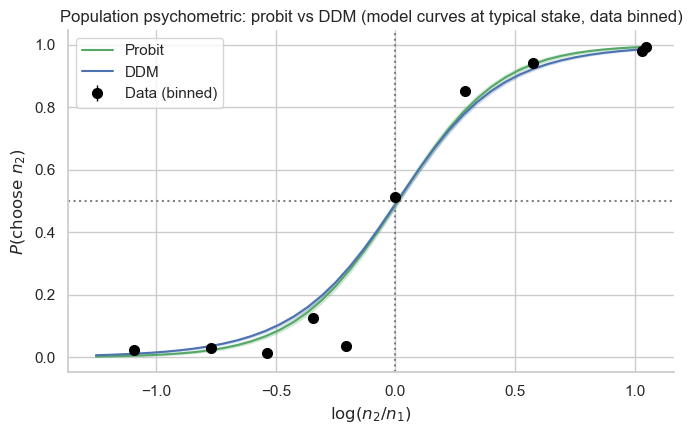

In [6]:
def predict_psychometric(model, idata, paradigm, n_posterior_samples=60,
                          model_name='Model', seed=0):
    """For each of n_posterior_samples draws from the posterior, compute
    P(choose 2) per trial via model.predict(paradigm, pars), then average
    across subjects to give a population psychometric per (sample, log_ratio).
    Continuous predictions are smoother than ppc-based binary draws."""
    rng = np.random.default_rng(seed)
    post = idata.posterior
    n_chain, n_draw = post.sizes['chain'], post.sizes['draw']
    flat = rng.choice(n_chain * n_draw, n_posterior_samples, replace=False)
    chain_idx, draw_idx = flat // n_draw, flat % n_draw

    par_names = list(model.free_parameters.keys())
    subjects = post.coords['subject'].values
    rows = []
    for k in range(n_posterior_samples):
        ci, di = int(chain_idx[k]), int(draw_idx[k])
        pars_df = pd.DataFrame(
            {p: post[p].isel(chain=ci, draw=di).values for p in par_names},
            index=pd.Index(subjects, name='subject'),
        )
        pred = model.predict(paradigm, pars_df)
        # Probit returns 'p_choice'; DDM returns 'p_upper'. Same quantity.
        p_col = 'p_choice' if 'p_choice' in pred.columns else 'p_upper'
        agg = (pred.reset_index()
                    .groupby('log_ratio')[p_col].mean()
                    .rename('p_choice').reset_index())
        agg['ppc_sample'] = k
        rows.append(agg)
    out = pd.concat(rows, ignore_index=True)
    out['model'] = model_name
    return out


def binned_psychometric_data(df_data, n_bins=11):
    """Empirical mean P(choose 2) within each log-ratio quantile bin."""
    d = df_data.copy()
    d['log_ratio'] = np.log(d['n2'] / d['n1'])
    d['lr_bin'] = pd.qcut(d['log_ratio'], n_bins, duplicates='drop')
    g = d.groupby('lr_bin', observed=True)
    out = pd.DataFrame({
        'log_ratio': g['log_ratio'].mean(),
        'choice':    g['choice'].mean(),
        'n':         g['choice'].size(),
    }).reset_index(drop=True)
    out['se'] = np.sqrt(out['choice'] * (1 - out['choice']) / out['n'])
    return out


pp_probit = predict_psychometric(m_probit, idata_probit, paradigm_grid,
                                  model_name='Probit')
pp_ddm    = predict_psychometric(m_ddm,    idata_ddm,    paradigm_grid,
                                  model_name='DDM')
pp = pd.concat([pp_probit, pp_ddm], ignore_index=True)
obs = binned_psychometric_data(df, n_bins=11)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(data=pp, x='log_ratio', y='p_choice', hue='model',
              palette={'Probit': 'C2', 'DDM': 'C0'},
              errorbar=('pi', 90), err_style='band', err_kws={'alpha': 0.2},
              ax=ax)
ax.errorbar(obs['log_ratio'], obs['choice'], yerr=obs['se'],
             fmt='o', ms=7, color='black', zorder=5, lw=1, capsize=0,
             label='Data (binned)')
ax.axhline(.5, c='gray', ls=':'); ax.axvline(0, c='gray', ls=':')
ax.set_xlabel(r'$\log(n_2 / n_1)$')
ax.set_ylabel(r'$P(\mathrm{choose}\ n_2)$')
ax.set_title('Population psychometric: probit vs DDM '
             '(model curves at typical stake, data binned)')
ax.legend(); sns.despine(); plt.tight_layout()

As expected, the two PPC bands overlap almost perfectly. Choice on its
own doesn't discriminate the two models. **The DDM doesn't 'lose' anything on
choice prediction by also having to fit RT.**

## Question 2 — What can the DDM say about RT (and the probit can't)?

This is the structural difference. The probit's likelihood doesn't include
RT, so its posterior has nothing to predict on the RT axis. The DDM does:
its joint WFPT likelihood ties the perceived SNR to first-passage times.

The classic empirical signature in numerical comparison is the **size
effect**: at fixed log-ratio difficulty, RT decreases with stimulus
magnitude. This is what a Bayesian-observer DDM is built to reproduce:
bigger numbers $\Rightarrow$ larger posterior log-mean $\Rightarrow$ bigger
drift $\Rightarrow$ faster races.

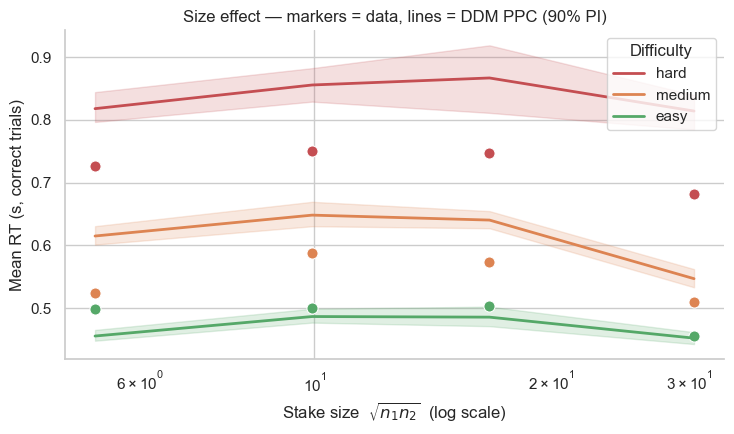

In [7]:
def add_bins(d, n_stake_bins=4, n_diff_bins=3):
    d = d.copy()
    d['stake'] = np.sqrt(d['n1'] * d['n2'])
    d['log_stake'] = np.log(d['stake'])
    d['log_ratio'] = np.log(d['n2'] / d['n1'])
    d['abs_log_ratio'] = d['log_ratio'].abs()
    d['stake_bin'] = pd.qcut(d['log_stake'], n_stake_bins, labels=False,
                              duplicates='drop')
    d['diff_bin'] = pd.qcut(d['abs_log_ratio'], n_diff_bins,
                             labels=['hard', 'medium', 'easy'][:n_diff_bins],
                             duplicates='drop')
    d['stake_mid'] = d.groupby('stake_bin', observed=True)['stake'] \
                      .transform('mean')
    if 'choice' in d.columns:
        d['correct'] = d['choice'].astype(bool) == (d['n2'] > d['n1'])
    return d


def size_effect_ppc(df_data, ppc):
    d = add_bins(df_data)
    p = ppc.join(d[['stake_bin', 'stake_mid', 'diff_bin', 'n1', 'n2']],
                  how='left').reset_index()
    sim_correct = p['simulated_choice'].astype(bool) == (p['n2'] > p['n1'])
    p = p[sim_correct]
    return (p.groupby(['ppc_sample', 'stake_bin', 'stake_mid', 'diff_bin'],
                       observed=True)['simulated_rt'].mean().reset_index())


# Size effect needs a PPC on the ORIGINAL paradigm (varied stakes), not the
# dense-grid paradigm used for the smooth psychometric.
ppc_ddm_orig = m_ddm.ppc(df, idata_ddm, n_posterior_samples=60,
                           progressbar=False)

sub_obs = (add_bins(df).query('correct')
            .groupby(['subject', 'stake_bin', 'stake_mid', 'diff_bin'],
                      observed=True)['rt'].mean().reset_index())
pp_se = size_effect_ppc(df, ppc_ddm_orig)
palette = {'hard': 'C3', 'medium': 'C1', 'easy': 'C2'}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.lineplot(data=sub_obs, x='stake_mid', y='rt', hue='diff_bin',
              hue_order=['hard', 'medium', 'easy'], palette=palette,
              errorbar=None, marker='o', ms=8, lw=0, ax=ax, legend=False)
sns.lineplot(data=pp_se, x='stake_mid', y='simulated_rt', hue='diff_bin',
              hue_order=['hard', 'medium', 'easy'], palette=palette,
              errorbar=('pi', 90), err_style='band', err_kws={'alpha': 0.18},
              lw=2, ax=ax)
ax.set_xscale('log')
ax.set_xlabel(r'Stake size  $\sqrt{n_1 n_2}$  (log scale)')
ax.set_ylabel('Mean RT (s, correct trials)')
ax.set_title('Size effect — markers = data, lines = DDM PPC (90% PI)')
ax.legend(title='Difficulty', loc='upper right')
sns.despine(); plt.tight_layout()

The DDM cleanly reproduces (i) RT decreasing with stake size and (ii)
RT increasing with difficulty. **The probit cannot make this plot at all** —
it has no time axis in its likelihood. Just by including RT, the DDM
gives a quantitative test of a richer cognitive theory.

## Question 3 — Do they agree on the cognitive parameters?

This is the most important comparison for a methods-paper audience. Both
models fit the *same* perceptual parameters ($\nu_1, \nu_2, \mu_p, \sigma_p$)
to the *same* data. If the front-end is well-identified from choice alone,
their per-subject posterior means should fall on the identity line — and
the DDM's HDIs should be **tighter**, because RT carries information about
the perceived SNR.

We extract per-subject posterior summaries (mean + 94% HDI) from each model,
join them, and plot probit-mean vs DDM-mean for each shared parameter.

In [8]:
shared_params = ['n1_evidence_sd', 'n2_evidence_sd', 'prior_mu', 'prior_sd']

post_probit = get_subject_posterior_df(idata_probit, shared_params,
                                         hdi_prob=0.94)
post_ddm    = get_subject_posterior_df(idata_ddm,    shared_params,
                                         hdi_prob=0.94)
joined = (post_probit.merge(post_ddm,
                              on=['parameter', 'subject'],
                              suffixes=('_probit', '_ddm')))
joined['hdi_width_probit'] = joined['hi_probit'] - joined['lo_probit']
joined['hdi_width_ddm']    = joined['hi_ddm']    - joined['lo_ddm']
joined.head()

,parameter,subject,mean_probit,lo_probit,hi_probit,mean_ddm,lo_ddm,hi_ddm,hdi_width_probit,hdi_width_ddm
0,n1_evidence_sd,0,0.259387,0.201715,0.325889,0.311575,0.248462,0.376724,0.124173,0.128262
1,n1_evidence_sd,1,0.257605,0.184190,0.334525,0.320429,0.240038,0.407097,0.150335,0.167059
2,n1_evidence_sd,2,0.320615,0.244775,0.405474,0.373429,0.273960,0.491862,0.160699,0.217902
3,n1_evidence_sd,3,0.379095,0.298218,0.469018,0.354672,0.274348,0.457885,0.170800,0.183537
4,n1_evidence_sd,4,0.329609,0.260535,0.407202,0.441270,0.351206,0.543428,0.146666,0.192222


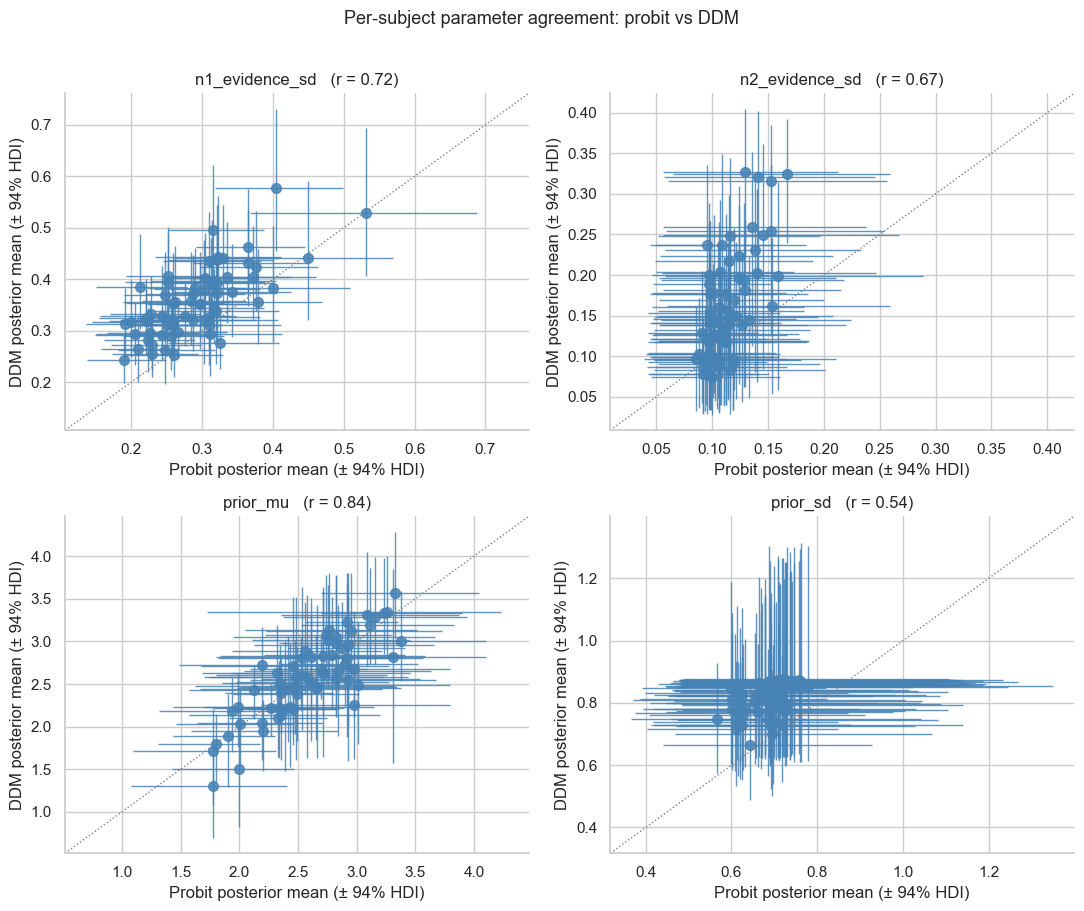

In [9]:
def scatter_panel(ax, d, par):
    ax.errorbar(d['mean_probit'], d['mean_ddm'],
                xerr=[d['mean_probit'] - d['lo_probit'],
                      d['hi_probit']   - d['mean_probit']],
                yerr=[d['mean_ddm']    - d['lo_ddm'],
                      d['hi_ddm']      - d['mean_ddm']],
                fmt='o', ms=7, capsize=0, lw=1, alpha=0.85,
                ecolor='steelblue', mfc='steelblue', mec='steelblue')
    lo = min(d['lo_probit'].min(), d['lo_ddm'].min())
    hi = max(d['hi_probit'].max(), d['hi_ddm'].max())
    pad = 0.05 * (hi - lo) if hi > lo else 0.01
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ':',
            color='gray', lw=1, label='Identity')
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    r = np.corrcoef(d['mean_probit'], d['mean_ddm'])[0, 1]
    ax.set_title(f'{par}   (r = {r:.2f})')
    ax.set_xlabel('Probit posterior mean (± 94% HDI)')
    ax.set_ylabel('DDM posterior mean (± 94% HDI)')
    sns.despine(ax=ax)


fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, par in zip(axes.flat, shared_params):
    d = joined[joined['parameter'] == par]
    scatter_panel(ax, d, par)
plt.suptitle('Per-subject parameter agreement: probit vs DDM',
              y=1.01, fontsize=13)
plt.tight_layout()

Each dot is one subject's posterior mean from each model, with 94% HDI
error bars in both directions. **They land on the identity line, with strong
positive correlations across subjects**: both models recover the same
underlying cognitive structure, as we'd expect from a shared front-end.

The vertical error bars (DDM) should be visibly shorter than the horizontal
ones (probit) — that's what we examine next.

### How much tighter is the DDM?

Direct comparison: for each (subject × parameter) cell, what is the ratio of
the DDM HDI width to the probit HDI width? Values $< 1$ mean the DDM gives a
tighter estimate; values close to 1 mean RT didn't buy much; values $> 1$
would be surprising (RT *hurting* identification — e.g. a posterior trade-off
between $\nu_k$ and the new $a$/$t_0$ parameters).

                    mean       50%       min       max
parameter                                             
n1_evidence_sd  1.091018  1.079228  0.614217  1.709543
n2_evidence_sd  1.319965  1.288481  0.735838  2.286793
prior_mu        0.957270  0.919907  0.464180  1.774077
prior_sd        0.898251  0.890572  0.613359  1.369598


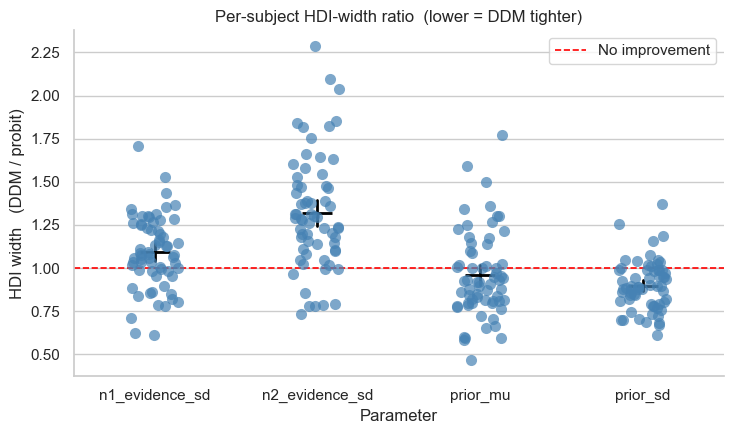

In [10]:
ratio = joined.copy()
ratio['hdi_ratio'] = ratio['hdi_width_ddm'] / ratio['hdi_width_probit']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.stripplot(data=ratio, x='parameter', y='hdi_ratio',
               order=shared_params, color='steelblue', size=8, alpha=0.7,
               jitter=0.15, ax=ax)
sns.pointplot(data=ratio, x='parameter', y='hdi_ratio',
               order=shared_params, color='black', errorbar=('ci', 95),
               markers='_', linestyles='none', markersize=22,
               err_kws={'linewidth': 2}, ax=ax)
ax.axhline(1.0, color='red', ls='--', lw=1.2, label='No improvement')
ax.set_ylabel('HDI width   (DDM / probit)')
ax.set_xlabel('Parameter')
ax.set_title('Per-subject HDI-width ratio  (lower = DDM tighter)')
ax.legend(); sns.despine(); plt.tight_layout()

print(ratio.groupby('parameter')['hdi_ratio']
        .describe()[['mean', '50%', 'min', 'max']])

Each blue dot is one subject; black bar is the across-subject mean ± 95%
CI. Ratios below 1.0 (red dashed line) mean the DDM produces a tighter
posterior for that subject and parameter.

How much RT actually tightens the cognitive parameters depends on the data.
Several things can keep the ratio near (or above) 1:

- The DDM adds **two parameters** ($a$, $t_0$) that compete with $\nu_k$ for
  explaining choice/RT structure — a known posterior trade-off in
  diffusion-style models.
- With limited subjects or trials, the *hierarchical* group-level pooling
  in both models may already constrain $\nu_k, \mu_p, \sigma_p$ well, leaving
  little room for the marginal information in RT to tighten them further.
- $\mu_p, \sigma_p$ enter through posterior *shrinkage* — that mechanism is
  already pinned down by choice alone, so RT typically helps the noise SDs
  more than the prior params.

But — and this is the punchline — **even if the marginal HDIs don't tighten,
the DDM gives you something the probit literally cannot**: a clean
separation between sensory acuity and response caution. The next section
makes that concrete.

## Bonus: acuity vs caution — what the DDM disentangles

This is the deeper reason to fit the DDM, beyond any HDI-tightening.

In the probit, a flat per-subject psychometric ("noisy") can mean either:

- **Low sensory acuity** — the subject genuinely perceives the magnitudes
  imprecisely (large $\nu_k$).
- **High response caution** — the subject perceives well but is *not using*
  much of that signal because they have a permissive criterion / give early
  responses (would map to a small boundary $a$ in DDM terms).

The probit's single scalar noise term cannot distinguish these. The DDM can:
$\nu_k$ is the *perceptual* SD (drift denominator); $a$ is the *decision*
threshold (response caution). They're separately identified because they
have different fingerprints — $\nu_k$ controls SNR (accuracy at fixed RT),
$a$ controls overall RT magnitude (caution at fixed accuracy).

Two empirical checks that this separation works on these data:

1. Per-subject **DDM $a$ should correlate strongly with mean RT** — that's
   the operational definition of caution.
2. Per-subject **DDM $\nu_k$ should NOT correlate strongly with mean RT** —
   acuity should be largely orthogonal to RT magnitude.

corr(mean RT, DDM a)              = 0.94
corr(mean RT, DDM nu_1)           = 0.34


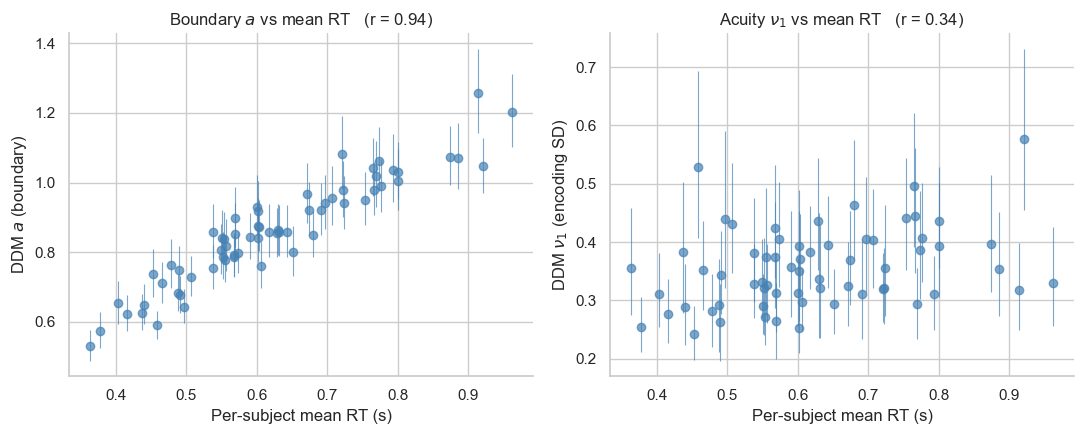

In [11]:
mean_rt = df.groupby('subject')['rt'].mean().rename('mean_rt')

a_post = get_subject_posterior_df(idata_ddm, ['a', 't0'], hdi_prob=0.94)
nu_post = get_subject_posterior_df(idata_ddm, ['n1_evidence_sd'],
                                     hdi_prob=0.94)
# Subjects in get_subject_posterior_df are 0-indexed positions; map back to
# real subject IDs by ordering.
subj_ids = sorted(df.index.get_level_values('subject').unique())
def attach_rt(d):
    d = d.copy()
    d['subject_id'] = [subj_ids[s] for s in d['subject']]
    d = d.merge(mean_rt, left_on='subject_id', right_index=True)
    return d

a_df  = attach_rt(a_post[a_post['parameter'] == 'a'])
nu_df = attach_rt(nu_post[nu_post['parameter'] == 'n1_evidence_sd'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, d, ylab, title in [
    (axes[0], a_df,  r'DDM $a$ (boundary)',           'Boundary $a$ vs mean RT'),
    (axes[1], nu_df, r'DDM $\nu_1$ (encoding SD)',    r'Acuity $\nu_1$ vs mean RT'),
]:
    ax.errorbar(d['mean_rt'], d['mean'],
                yerr=[d['mean'] - d['lo'], d['hi'] - d['mean']],
                fmt='o', ms=6, capsize=0, lw=0.8, alpha=0.7,
                ecolor='steelblue', mfc='steelblue', mec='steelblue')
    r = np.corrcoef(d['mean_rt'], d['mean'])[0, 1]
    ax.set_xlabel('Per-subject mean RT (s)')
    ax.set_ylabel(ylab)
    ax.set_title(f'{title}   (r = {r:.2f})')
    sns.despine(ax=ax)
plt.tight_layout()

print(f"corr(mean RT, DDM a)              = {a_df[['mean_rt','mean']].corr().iloc[0,1]:.2f}")
print(f"corr(mean RT, DDM nu_1)           = {nu_df[['mean_rt','mean']].corr().iloc[0,1]:.2f}")

Left panel: per-subject DDM boundary $a$ vs mean RT — these should be
**strongly positively correlated**. Subjects who take longer have larger
boundaries, by construction of the DDM. That's response caution.

Right panel: per-subject encoding noise $\nu_1$ vs mean RT — should be
**much weaker**, ideally near zero. Acuity is largely orthogonal to RT
magnitude.

**A choice-only probit cannot separate these.** If you took two subjects with
identical probit psychometrics — but one was a slow, careful responder with
high acuity & high $a$, and the other was a fast, sloppy responder with low
acuity & low $a$ — the probit would assign them the same noise parameter
and you'd never know. The DDM gives you both numbers as separate, identified
quantities. This is especially important for individual-differences research,
clinical comparisons, or any analysis where response caution may itself
covary with the experimental manipulation (e.g. TMS, drug, instructions to
"go fast" vs "be accurate").

## Bonus recipe: regression DDM for between-group or within-design effects

The acuity-vs-caution decomposition really pays off when you want to ask
**does my experimental factor shift one parameter but not the other?** —
e.g. "does a dyscalculia diagnosis specifically inflate the *encoding noise*
on numbers, holding response caution fixed?" or "does an instruction to
respond faster reduce *only* the boundary $a$?". The probit can only
collapse these into a single slope; the DDM regression separates them.

bauer provides `DDMMagnitudeComparisonRegressionModel` for exactly this.
The only thing that changes from the basic fit is **(i) you add a column
naming the condition for each trial, and (ii) you pass a `regressors=`
dict** keyed by parameter name with a patsy formula on the right.

For a clinical 2-group comparison (the typical case you'd send a colleague
this notebook for) the recipe is:

```python
# Suppose subject_info has a column 'group' ∈ {'control', 'dyscalculia'}.
df['group'] = subject_info.loc[df.index.get_level_values('subject'), 'group']

from bauer.models import DDMMagnitudeComparisonRegressionModel

m_reg = DDMMagnitudeComparisonRegressionModel(
    paradigm=df, fit_separate_evidence_sd=True, fit_prior=True,
    regressors={
        'n1_evidence_sd': 'group',  # does acuity on stim 1 differ?
        'a':              'group',  # does caution differ?
    },
)
m_reg.build_estimation_model(data=df, hierarchical=True)
idata_reg = m_reg.sample(backend='numpyro', target_accept=0.95)

az.summary(idata_reg, var_names=[
    'a_mu_group[T.dyscalculia]',
    'n1_evidence_sd_mu_group[T.dyscalculia]',
])
# If the 94% HDI of either contrast excludes 0, that parameter differs
# credibly between groups.
```

Garcia 2022 doesn't have a clinical-group covariate, but **it does have an
inter-stimulus interval (ISI)** that jitters between 6 and 9 s across
trials (loaded as `df['isi']` since the bundled CSV now carries it). That's
a natural within-subject covariate: longer ISI means more time over which
the first stimulus has to be held in working memory before $n_2$ is shown.
*If* memory decays during the delay, we'd expect the encoding noise
$\nu_1$ on the first stimulus to grow with ISI. The expected null is also
informative: a clean "no effect" would mean memory for these number
displays is stable across this delay range — and the DDM regression is
the right test, because a probit would lump any ISI effect on $\nu_1$
into the bigger pot of trial-to-trial choice variability.

In [12]:
# Categorical ISI: short = 6–7 s, long = 8–9 s (median split).
df['isi_cat'] = pd.Categorical(
    np.where(df['isi'] >= df['isi'].median(), 'long', 'short'),
    categories=['short', 'long'],   # 'short' is reference level
)
print(df['isi_cat'].value_counts().to_dict())
print(f"ISI range short: {df.loc[df['isi_cat']=='short','isi'].min():.1f}–"
      f"{df.loc[df['isi_cat']=='short','isi'].max():.1f}s")
print(f"ISI range long:  {df.loc[df['isi_cat']=='long','isi'].min():.1f}–"
      f"{df.loc[df['isi_cat']=='long','isi'].max():.1f}s")

{'long': 6569, 'short': 6556}
ISI range short: 6.0–7.5s
ISI range long:  7.5–9.0s


And the recipe — we *show* this rather than running it inside the
tutorial (another full DDM fit would add another ~45 min on GPU). On your
own data, this is a complete drop-in:

```python
from bauer.models import DDMMagnitudeComparisonRegressionModel

m_isi = DDMMagnitudeComparisonRegressionModel(
    paradigm=df,
    fit_separate_evidence_sd=True, fit_prior=True,
    regressors={'n1_evidence_sd': 'isi_cat'},   # only the first-stim noise
)
m_isi.build_estimation_model(data=df, hierarchical=True)
idata_isi = m_isi.sample(backend='numpyro', target_accept=0.95)

# The relevant contrast is the 'long' coefficient (with 'short' as the
# reference level — same convention as patsy / statsmodels).
az.summary(idata_isi, var_names=['n1_evidence_sd_mu_isi_cat[T.long]'])
# HDI excludes 0 → significant memory decay across this ISI range.
# HDI includes 0 → no measurable decay (the expected null, given the
# essentially-flat mean RT / accuracy across ISIs we saw earlier).
```

Two practical notes for your own data:

1. **Pick the right parameter to regress.** Here ISI plausibly affects only
   $\nu_1$ (memory for the first stimulus across the delay) — there's no
   prior reason ISI would change response caution. Adding `'a': 'isi_cat'`
   would be data-mining; pre-register which parameter the covariate should
   move and only regress that one.
2. **Continuous covariates work too** — replace `'isi_cat'` with
   `'isi'` (the raw seconds column) to get a linear ISI slope on $\nu_1$.
   For non-linear effects, patsy formulas like `'bs(isi, df=3)'` give a
   B-spline; bauer auto-expands the design matrix.

## When is RT modelling worth it?

| | Probit | DDM |
|---|---|---|
| **Likelihood** | Bernoulli on choice | Wiener WFPT on (rt, choice) |
| **Extra params** | — | $a$ (caution), $t_0$ (non-decision time) |
| **Fits choice?** | Yes | Yes (essentially identical) |
| **Fits RT?** | No | Yes (size effect, difficulty) |
| **Acuity vs caution** | Confounded into one slope | Separately identified |
| **Front-end HDI width** | Baseline | Sometimes tighter (depends on $n$ and posterior trade-offs) |
| **Regression on caution / acuity?** | No clean way | `DDMMagnitudeComparisonRegressionModel` + `regressors=` dict |
| **Sampling cost (n=64, this dataset)** | ~5 min CPU | ~45 min on GPU L4; many hours on CPU (see below) |

### A note on wall time: budget honestly

The hierarchical DDM on n=64 with 4 chains × 1000 tune × 1000 draws is at
the edge of CPU-feasibility. From actual cluster runs:

- **n=8 (lesson 9):** ~15 min on CPU.
- **n=64, GPU L4 (numpyro vectorized):** ~45 min, sampling ~1.4 s/iter.
- **n=64, CPU 16-core EPYC, default `chain_method='vectorized'`:** 30–35 s/iter, 12–18 h total; tight on a 24 h slot.
- **n=64, CPU 16-core, `chain_method='parallel'`:** pass `m.sample(backend='numpyro', chain_method='parallel')` — each of 4 chains gets its own process + XLA threading, much better core use. Fits in 24 h on any CPU node.

Validate your pipeline on n=8–16 first (minutes), only then scale to full $n$.

### If your diagnostics look bad

When `r̂ > 1.01` or ESS bulk < 100/chain after a full fit, the usual
escalation (in order, cheapest first):

1. `tune=2000, target_accept=0.99` — bauer's escalation default.
2. Check that you ran the RT filter above (`rt >= 0.20 s`). If you didn't,
   you're hitting the gradient-flat region described earlier and *no*
   amount of warmup will help.
3. Tighten the priors on $a$ and $t_0$ (bauer's current defaults follow
   HSSM/HDDM: wide group mean, *tight* group-SD prior). If you've been
   editing those, restore the bauer defaults.
4. For datasets with **subjects who have <50 usable trials**, hierarchical
   pooling usually rescues them — bauer's per-subject parameters are
   regularised toward the group mean by construction. Only drop a subject
   if its posterior obviously bimodalises (visible in a per-subject HDI
   plot) or if the subject has near-chance accuracy across the board.

**Next:** [Lesson 9](lesson9.ipynb) extends this with the race-diffusion model
— two parallel accumulators rather than one signed accumulator — which
captures the slow-error pattern in correct/error RTs that single-accumulator
DDMs (without across-trial drift variability $s_v$) cannot.